In [1]:
import os, sys, glob
# from abc import ABCMeta, abstractmethod, abstractproperty
import abc
from enum import Enum
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
import json

import space_phot
from astropy.io import fits
from jwst.associations import asn_from_list
from jwst.associations.lib.rules_level3_base import DMS_Level3_Base
from jwst.pipeline import Image3Pipeline
from jwst.skymatch import SkyMatchStep
from jwst.datamodels import ModelLibrary

# Hack - I moved this into a local notebooks dir...
sys.path.append("/Users/dcoulter/Code/diffpype/src/jwst_diff")
from image1overf import sub1fimaging

sys.path.append("/Users/dcoulter/Code/diffpype/src/workflow_manager")
from data_repository import RepositoryFactory 
from data_utils import DataUtils
from visualization import Visualizer


from shapely.geometry import Point
from shapely.geometry.polygon import Polygon

from mocpy import MOC
from mocpy import WCS as mocWCS
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from astropy.time import Time
import numpy as np

import pandas as pd
import mysql.connector

import mysql.connector
from mysql.connector import Error
from mysql.connector.pooling import MySQLConnectionPool
from pprint import pprint
import math

import pdb

import healpy as hp





The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


In [2]:
import sys
print(sys.executable)

/opt/miniconda3/envs/diffpype/bin/python


In [2]:
jwst_sw_linear_size = 1.054 # arcmin on a side
jwst_sw_module_area_sq_deg = (2040*0.031/3600)**2
print("\nArea per JWST SW module: %s deg^2" % jwst_sw_module_area_sq_deg)

JWST_MODULE_NSIDE = 2097152
power_of_two = int(np.log10(JWST_MODULE_NSIDE)/np.log10(2))
print("Max Depth: %s" % power_of_two)
jwst_hp_area_sq_deg = hp.nside2pixarea(nside=JWST_MODULE_NSIDE, degrees=True)
print("Area per JWST_MODULE_NSIDE %s pixel: %s deg^2" % (JWST_MODULE_NSIDE, jwst_hp_area_sq_deg))

hp_per_jwst = jwst_sw_module_area_sq_deg/jwst_hp_area_sq_deg
print("JWST_MODULE_NSIDE pixels per native JWST SW module: %s" % hp_per_jwst)

GLOBAL_CONFIG = {
    "mysql_config": {
        'host': '127.0.0.1',
        'port':'3307', # SSH Port Forward from Massimo's Burton machine
        'database': 'diffpype2',
        'user': 'dev',
        'password': 'devpass'
    },
    "filesystem_config": {
        "mast_proxy":"/astro/armin/Dave/NEXUS/MAST_2026-06-18T2015/JWST/flattened",
        "base_dir":"/astro/armin/Dave/NEXUS/diffpype_root/working_pipeline"
    },
    "moc_settings":{
        "moc_max_depth":power_of_two
    }

}

repo_type = "mysql"
data_repo = RepositoryFactory.get_repository(repo_type, GLOBAL_CONFIG)

# Retrieve images hits the db to get images. This will come from a MAST query in the future
# image_df = data_repo.retrieve_images()
# print(len(image_df))


project_name = 'NEXUS'
project_df = data_repo.save_project(project_name)
pprint(project_df)
project_id = project_df.loc[0, 'id']

data_repo.set_project_context(project_df)


Area per JWST SW module: 0.0003085877777777778 deg^2
Max Depth: 21
Area per JWST_MODULE_NSIDE 2097152 pixel: 7.816531185164738e-10 deg^2
JWST_MODULE_NSIDE pixels per native JWST SW module: 394788.6478895614
DataUtils instance initialized with `moc_max_depth`: 21
Connection pool 'mypool' initialized with size 5.
Returning Project: NEXUS
Record already exists! Returning existing...
   id   name
0   1  NEXUS
Project directories created.


In [6]:
#Helpful re-load
import importlib
import visualization
import data_repository
import data_utils

importlib.reload(visualization)
importlib.reload(data_repository)
importlib.reload(data_utils)

viz = visualization.Visualizer("/Users/dcoulter/Code/notebooks/diffpype/images/")

In [4]:
# Execute MAST query (proxy) to get raw image files into the raw image dir
raw_images = data_repo.get_images_from_MAST()
# data_repo.save_images(raw_images)

Created symlink: '/astro/armin/Dave/NEXUS/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014016_06101_00001_nrcalong_cal.fits' -> '/astro/armin/Dave/NEXUS/MAST_2026-06-18T2015/JWST/flattened/jw05105014016_06101_00001_nrcalong_cal.fits'
Created symlink: '/astro/armin/Dave/NEXUS/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105003002_03201_00002_nrcb1_cal.fits' -> '/astro/armin/Dave/NEXUS/MAST_2026-06-18T2015/JWST/flattened/jw05105003002_03201_00002_nrcb1_cal.fits'
Created symlink: '/astro/armin/Dave/NEXUS/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105014004_06101_00002_nrcb3_cal.fits' -> '/astro/armin/Dave/NEXUS/MAST_2026-06-18T2015/JWST/flattened/jw05105014004_06101_00002_nrcb3_cal.fits'
Created symlink: '/astro/armin/Dave/NEXUS/diffpype_root/working_pipeline/NEXUS/rawimage/jw05105004005_02101_00002_nrcb2_cal.fits' -> '/astro/armin/Dave/NEXUS/MAST_2026-06-18T2015/JWST/flattened/jw05105004005_02101_00002_nrcb2_cal.fits'
Created symlink: '/astro/armin/Dave/NEXUS/diffpype

In [6]:
# Filter which of these files we wish to enter the pipeline -- e.g., remove everything with exp_time < 100 seconds, etc.
IMAGE_WHERE = [
    'exp_time > 10.0',
    'id > 0'
]

# Save images to Lvl2Cal table
lvl2_df = data_repo.import_images_to_lvl2cals(IMAGE_WHERE)

# Or, if they already exist:
# lvl2_df = data_repo.retrieve_lvl2_cals()

pprint(len(lvl2_df))

Performing UPSERT of lvl2 cals to the database...
Returning Image JOIN with Lvl2s table from database.
3672


In [9]:
unioned_image_moc = DataUtils.Get_Unioned_MOC(lvl2_df.moc)
tiles_df = DataUtils.GenerateSkyTiles(project_id=project_id,
                                            tile_side_length_arc_min=2.5,
                                            overlap_in_arc_min=0.25,
                                            moc_to_tile=unioned_image_moc)

print(len(tiles_df))

0.0375
0.0375
All Sky statistics
	Num of dec strips: 4799
	Northern most dec: 89.94372222222223
	Southern most dec: -89.98125
	Eastern most ra: 359.94372222121973
	Western most ra: 0.01875000100250066
	Num of ra tiles in northern most dec slice: 10
	Num of ra tiles at celestial equator: 9599
Constructing grid of coordinates...
Number of coords near (268.4633, 65.2006) within a 0.6620 deg radius: 977
105


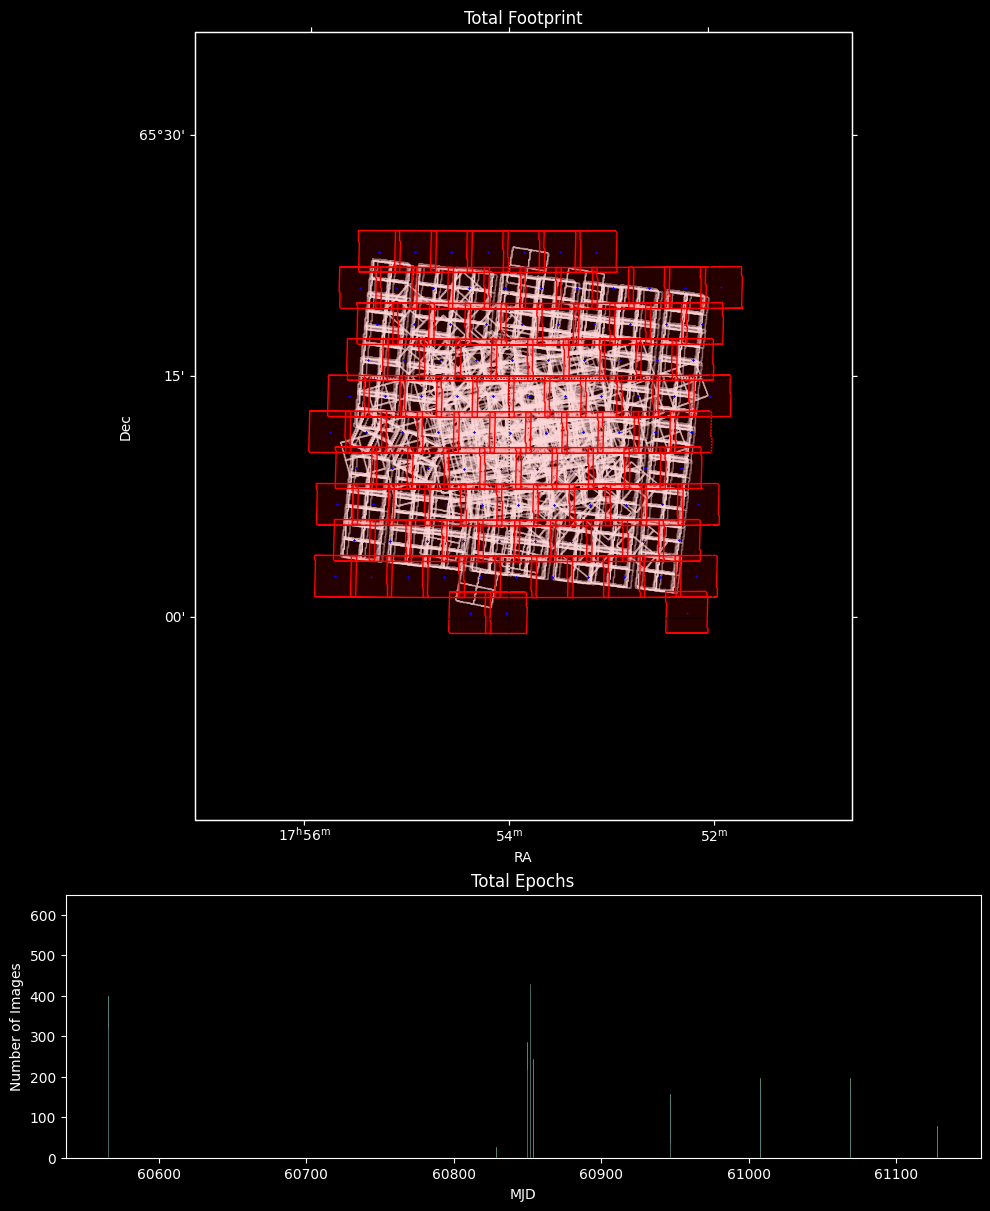

In [22]:
unioned_tile_moc = DataUtils.Get_Unioned_MOC(tiles_df.moc)

covered_area = unioned_tile_moc.sky_fraction*41253
fov_proxy = 1.75*np.sqrt(covered_area) # add a fudge factor since areas aren't circles...
barycenter = unioned_tile_moc.barycenter()

# viz = Visualizer("/Users/dcoulter/Code/notebooks/diffpype/images/")
viz.plot_footprint_and_epochs(moc_list=lvl2_df.moc, 
                              epoch_list=lvl2_df.mjd_avg, 
                              footprint_title="Total Footprint", 
                              hist_title="Total Epochs", 
                              central_coord=barycenter, 
                              fov_degrees=fov_proxy, 
                              tile_df=tiles_df)

In [3]:
project_df = data_repo.retrieve_project(project_name)
image_df = data_repo.retrieve_images()
lvl2_df = data_repo.retrieve_lvl2_cals()
tiles_df = data_repo.retrieve_tiles(project_name)
tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
lvl3mosaic_df = data_repo.retrieve_lvl3mosaic_by_project(project_name)


Returning Project: NEXUS
Returning image table from database.
Returning Image JOIN with Lvl2s table from database.
Returning Project: NEXUS
Returning tiles for Project: NEXUS
Returning Project: NEXUS
Returning tile-lvl2 relation for Project: NEXUS
Returning Project: NEXUS
Returning Lvl3Mosaic JOIN with Tile and Epoch from database for Project: `NEXUS`


In [12]:
print(len(raw_images))
print(len(lvl2_df.moc))

3672
3672


In [13]:
tiles_df = data_repo.save_tiles(tiles_df, project_name, clobber=True)

Returning Project: NEXUS
Tiles for `NEXUS` do not exist
Returning tiles for Project: NEXUS
Returning Project: NEXUS
Returning tiles for Project: NEXUS


In [14]:
tile_image_dict = data_repo.save_tile_image_association(project_name, tiles_df, lvl2_df)

Returning Project: NEXUS
Returning Project: NEXUS
Returning tile-lvl2 relation for Project: NEXUS


In [15]:
tile_ids = tile_image_dict.keys()
tile_names = [tiles_df[tiles_df["id"]==_id].name.iloc[0] for _id in tile_ids]


print("Tile ID, Tile Name, Filter Tuples")
for _id, _name in zip(tile_ids, tile_names):
    band_id_per_tile = tile_image_dict[_id].band_id.to_list()
    _tmp_b = []
    for b in band_id_per_tile:
        _tmp_b.append(b)
    uniq_b = set(_tmp_b)
    b_names = [data_repo.reverse_bands[b] for b in uniq_b]
    print(_id, _name, [(b_id, b_name) for (b_id, b_name) in zip(uniq_b, b_names)])

Tile ID, Tile Name, Filter Tuples
1 Tile_1 [(9, 'F090W')]
2 Tile_2 [(16, 'F360M'), (12, 'F210M')]
3 Tile_3 [(16, 'F360M'), (12, 'F210M')]
4 Tile_4 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (8, 'F444W'), (9, 'F090W')]
5 Tile_5 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (8, 'F444W'), (9, 'F090W'), (12, 'F210M'), (16, 'F360M')]
6 Tile_6 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (8, 'F444W'), (9, 'F090W'), (12, 'F210M'), (16, 'F360M')]
7 Tile_7 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (8, 'F444W'), (9, 'F090W'), (12, 'F210M'), (16, 'F360M')]
8 Tile_8 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (8, 'F444W'), (9, 'F090W'), (12, 'F210M'), (16, 'F360M')]
9 Tile_9 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (8, 'F444W'), (9, 'F090W'), (12, 'F210M'), (16, 'F360M')]
10 Tile_10 [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (8, 'F444W'), (9, 'F090W'), (12, 'F210M'), (16, 'F360M')]
11 Tile_11 [(1, 'F115W

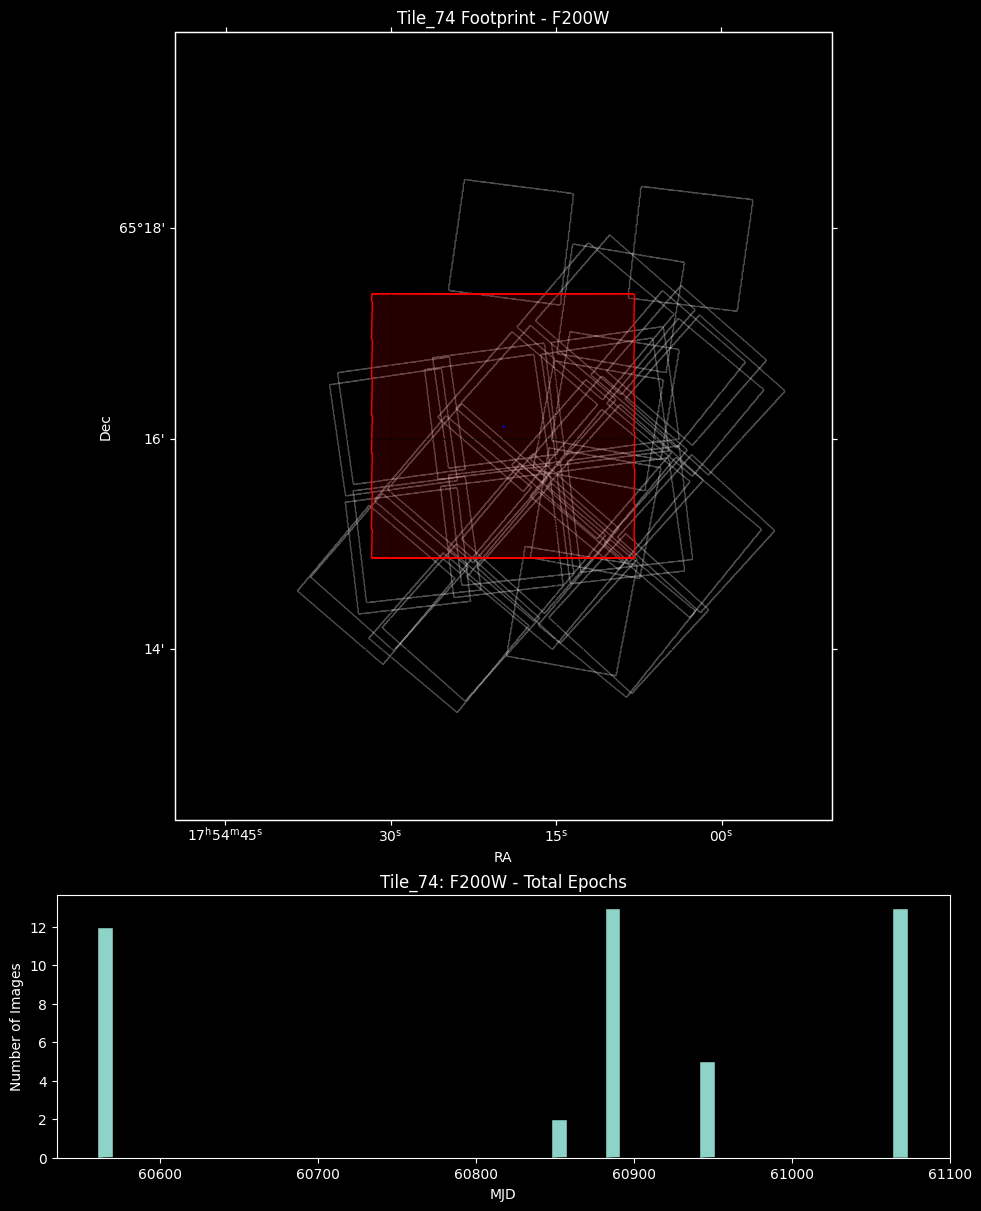

In [8]:
tile_id = 74
filter_tups = [(3, 'F200W')] # , (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (8, 'F444W'), (9, 'F090W'), (12, 'F210M'), (16, 'F360M')

viz.plot_tile_contents(image_dataframe=tile_image_dict[tile_id], tile_dataframe=tiles_df, filter_tuples=filter_tups, tile_id=tile_id, fov_scale=2.5, thick=True)

In [38]:
# print(len(tile_image_dict[tile_id]))

print(tile_image_dict.keys())

tile_bb = tile_image_dict[74]
f200_tile_74 = tile_bb[tile_bb.band_id == 3]
num_images = f200_tile_74[(f200_tile_74.mjd_avg <= 61079) & (f200_tile_74.mjd_avg >= 61058)]

print(max(f200_tile_74.mjd_avg))

print(len(num_images))


# images_in_tile[images_in_tile["band_id"] == _band_id]


dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105])
61068.48084575232
13


In [19]:
do_save = True
distance_thresh = 10

# For tile, for filter -> grab epochs from the resulting image list
for tile_id, images_in_tile in tile_image_dict.items():

    for _band_id in images_in_tile["band_id"].unique():

        in_band_images = images_in_tile[images_in_tile["band_id"] == _band_id]
        in_band_mjds = list(in_band_images.mjd_avg)
        epochs = DataUtils.CreateEpochsFromMJDs(in_band_mjds, peak_distance_thresh=distance_thresh)

        if do_save:
            data_repo.save_tile_epochs(start_mjds=epochs[:,0], end_mjds=epochs[:,1], tile_id=tile_id, band_id=_band_id, project_id=project_id)

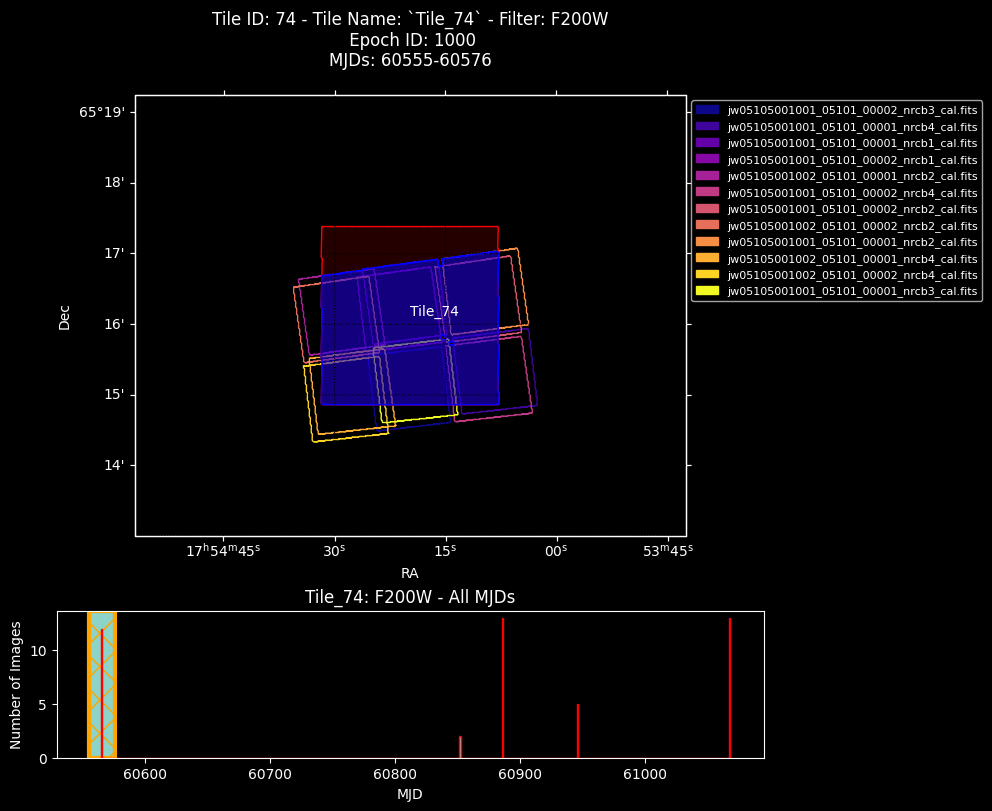

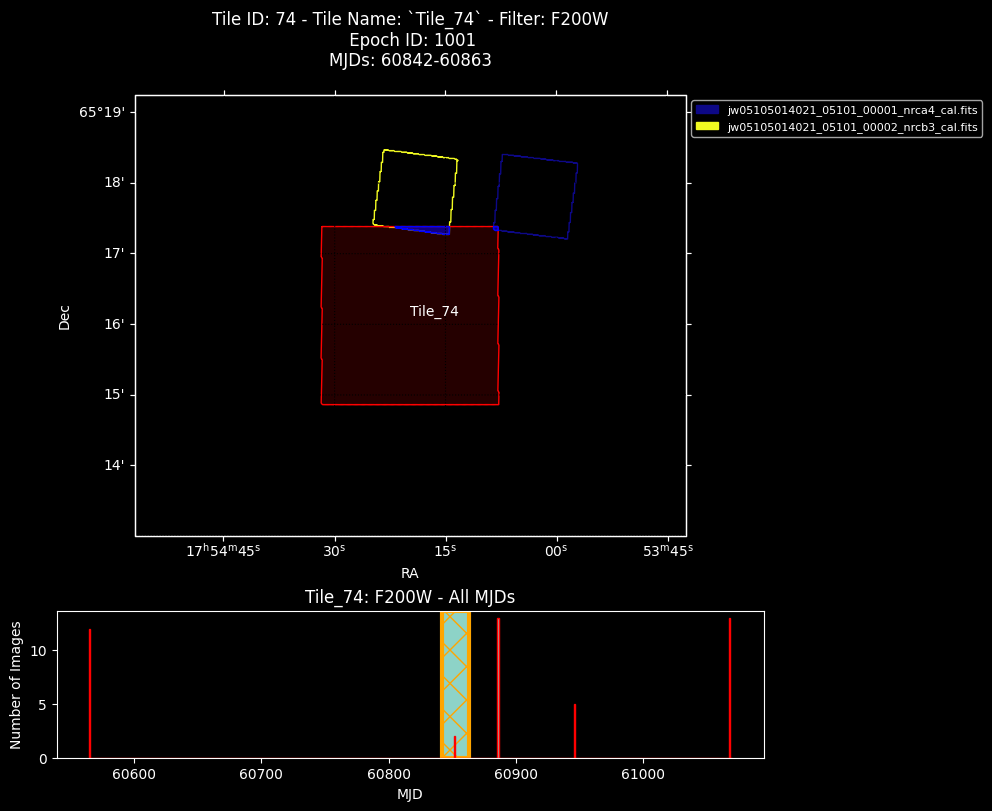

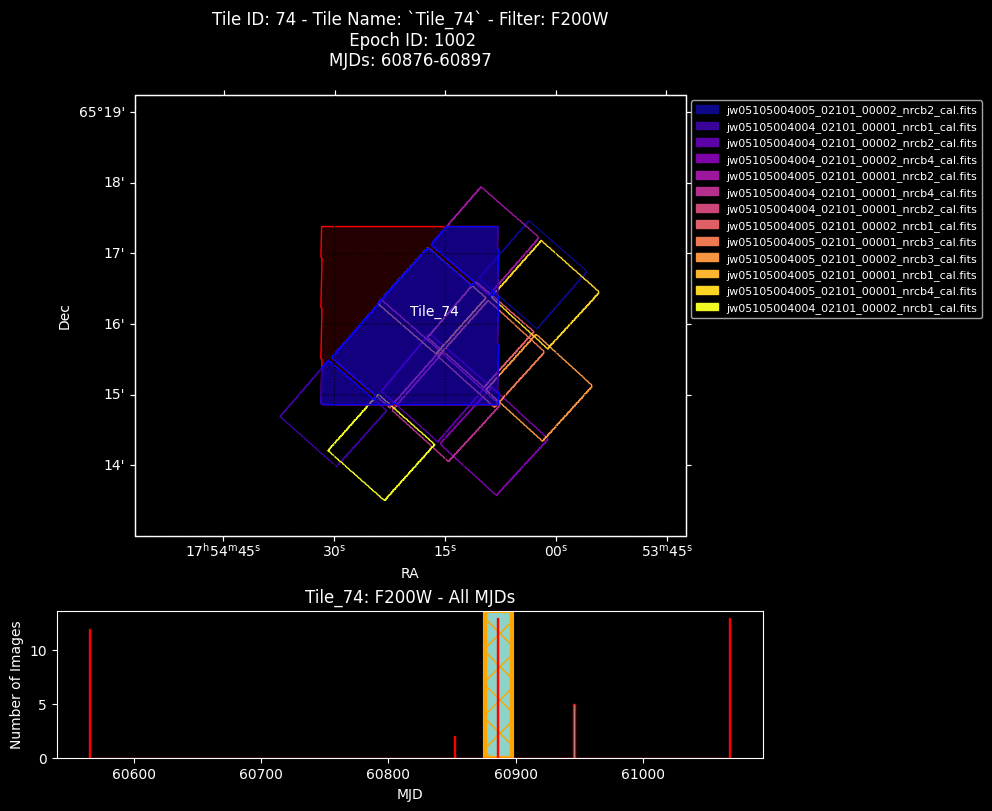

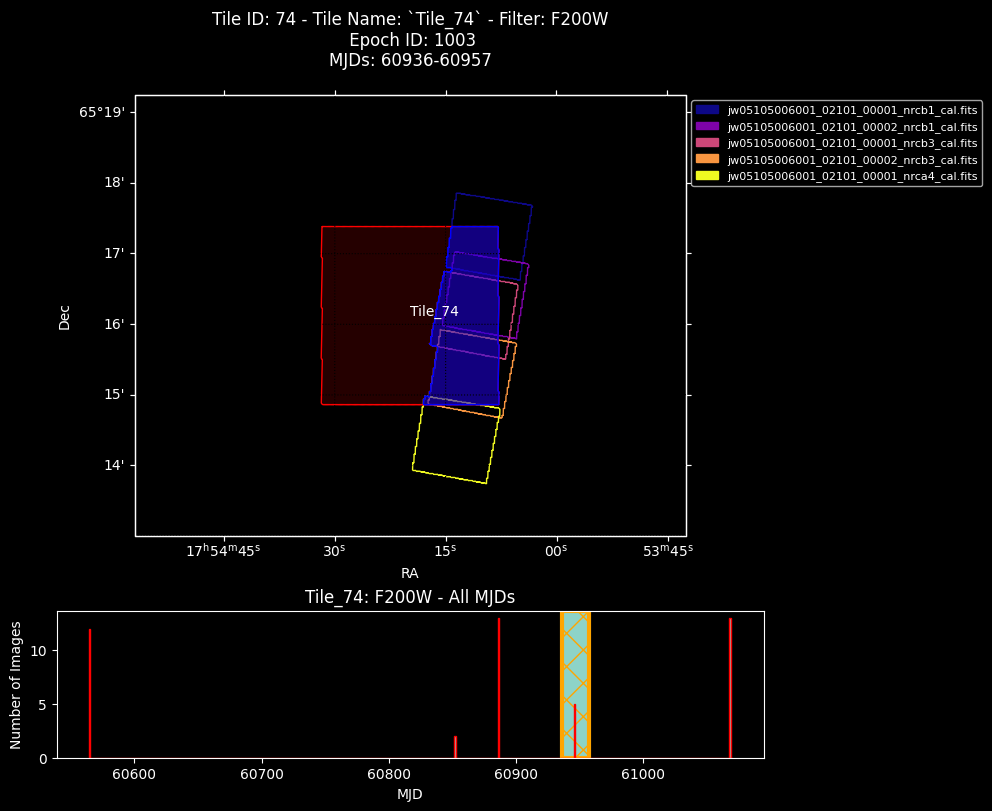

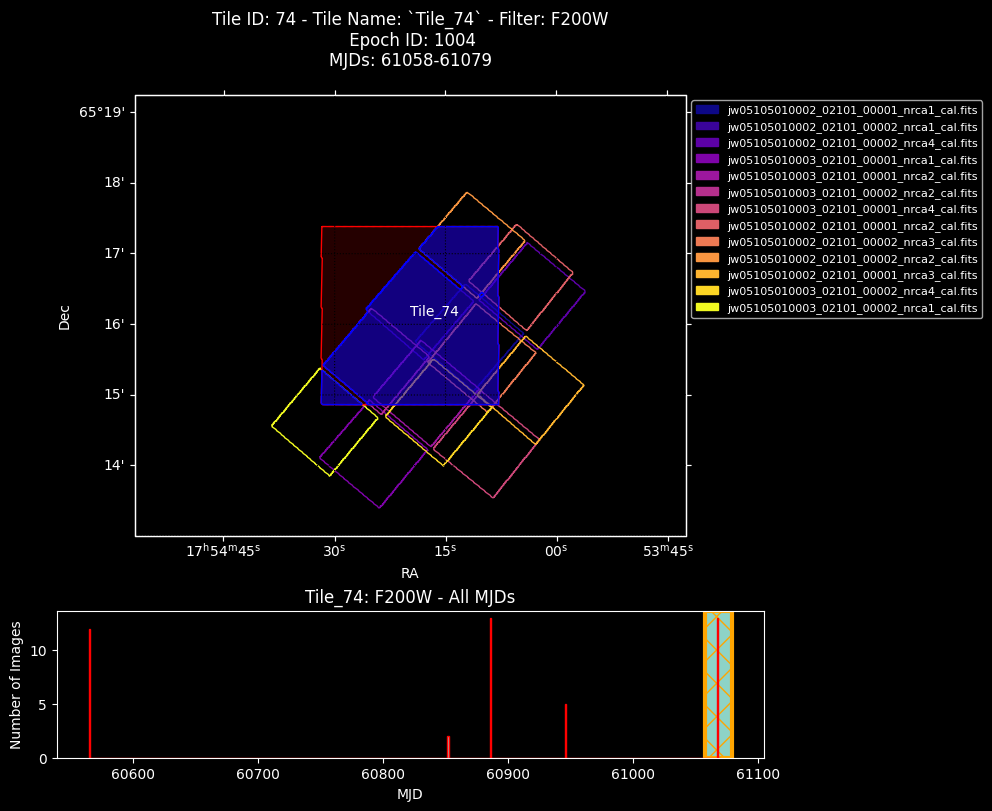

In [9]:
# Plot any combination of tile and band
_tile_id = 74
_tile_filter_tuple = (3, 'F200W')


_tile_df = tiles_df[tiles_df["id"] == _tile_id]
_tile_obj = _tile_df.iloc[0]
_tile_epochs = data_repo.retrieve_tile_epochs(tile_id=_tile_id, band_id=_tile_filter_tuple[0], project_id=project_id)
_tile_img_df = tile_image_dict[_tile_id]

for _tp_index, _tp in _tile_epochs.iterrows():
    _ep_start = _tp["start_mjd"]
    _ep_stop = _tp["end_mjd"]

    _in_epoch_imgs = _tile_img_df[(_tile_img_df.mjd_avg >= _ep_start) & (_tile_img_df.mjd_avg <= _ep_stop) & (_tile_img_df.band_id == _tile_filter_tuple[0])]

    viz.plot_epochs(all_image_dataframe=_tile_img_df, epoch_image_dataframe=_in_epoch_imgs, tile_dataframe=tiles_df, filter_tuple=_tile_filter_tuple, tile_id=_tile_id, fov_scale=2.5, epoch_record=_tp)

    # break

In [63]:
# Save tile-epoch-lvl2 => mosaic
# We have to create a lvl3 record, and then use the ID to create the lvl2->lvl3 lookup table to create the mosaic
#   Mosaic = Tile ID, Band ID, Epoch ID

# Iterate over all tiles
#   Over all unique bands
#       Over all enclosed images by band
#       Group by epoch
#           Save unique combo of tile_id, band_id, image_id, epoch_id
for tile_id, lvl2_in_tile in tile_image_dict.items():

    for band_id in lvl2_in_tile["band_id"].unique():
        in_band_tile_epochs = data_repo.retrieve_tile_epochs(tile_id=tile_id, band_id=band_id, project_id=project_id)

        for index, epoch in in_band_tile_epochs.iterrows():

            # Create lvl2-epoch records
            start_mjd = epoch["start_mjd"]
            end_mjd = epoch["end_mjd"]
            epoch_id = epoch["id"]
            in_epoch_lvl2 = lvl2_in_tile[(lvl2_in_tile.mjd_avg >= start_mjd) & (lvl2_in_tile.mjd_avg <= end_mjd) & (lvl2_in_tile.band_id == band_id)]

            # Save the association
            lvl2_epoch_assc = data_repo.save_epoch_lvl2cal_association(epoch_id, in_epoch_lvl2)

            # Create lvl3mosaic obj
            lvl3mosaic = data_repo.save_lvl3mosaic(project_id, tile_id, band_id, epoch_id, in_epoch_lvl2)

Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from da

In [64]:
lvl3mosaic_df = data_repo.retrieve_lvl3mosaic_by_project(project_name)

Returning Project: NEXUS
Returning Lvl3Mosaic JOIN with Tile and Epoch from database for Project: `NEXUS`


In [10]:
# print(lvl3mosaic_df.columns)

lvl3mosaic_to_make = lvl3mosaic_df[(lvl3mosaic_df.band_id == 3) & (lvl3mosaic_df.tile_id == 74) & (lvl3mosaic_df.epoch_id == 1004)]
lvl3_obj = lvl3mosaic_to_make.iloc[0]
print(lvl3_obj)

lvl3mosaic_id                                                        1004
target_plate_scale                                                   30.0
filename                NEXUS_NIRCAM_Tile_74_F200W_61058.0_61079.0_30....
band_id                                                                 3
epoch_id                                                             1004
instrument_id                                                           1
lvl3mosaic_status_id                                                    1
tile_id                                                                74
footprint_moc           12/41933787 41933809 41933811 \n13/167735131 1...
project_id                                                              1
ra                                                             268.582556
decl                                                            65.268726
tile_moc                12/41933811-41933812 41933814 41933817 \n13/16...
start_mjd                             

In [20]:
from concurrent.futures import ProcessPoolExecutor, as_completed

sys.path.append("/Users/dcoulter/Code/diffpype/src/steps")

import Executors
import OneOverF
import BkgSub
import Mosaic
import importlib

importlib.reload(OneOverF)
importlib.reload(Executors)
importlib.reload(BkgSub)
importlib.reload(Mosaic)

<module 'Mosaic' from '/Users/dcoulter/Code/diffpype/src/steps/Mosaic.py'>

In [16]:


# project_df = data_repo.retrieve_project(project_name)
# image_df = data_repo.retrieve_images()
# lvl2_df = data_repo.retrieve_lvl2_cals()
# tiles_df = data_repo.retrieve_tiles(project_name)
# tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
# lvl3mosaic_df = data_repo.retrieve_lvl3mosaic_by_project(project_name)

# lvl3_gb = lvl3mosaic_df.groupby(by=['tile_id','band_id']).epoch_id.nunique()>2
# lvl3_todo = lvl3_gb[lvl3_gb].reset_index()
lvl3mosaic_to_make

print("Running mosaic")
# mosaic
inpdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])
outdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])
logdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'logs/mosaic'])

lvl2_in = []
mosaic_out = []
tile_params = []

for mosaic_id in lvl3mosaic_to_make.index:

    mosaic = lvl3mosaic_to_make.loc[mosaic_id]
    tile_id = mosaic.tile_id
    epoch_id = mosaic.epoch_id
    band_id = mosaic.band_id


    mosaic_out.append(mosaic.filename)

    pix_scale = mosaic.target_plate_scale / 1000
    CRVAL1 = mosaic.ra
    CRVAL2 = mosaic.decl
    tile_shape = np.array((tiles_df[tiles_df.id == tile_id].iloc[0].delta_ra, tiles_df[tiles_df.id == tile_id].iloc[0].delta_decl)) * 3600 / pix_scale
    CRPIX1, CRPIX2 = tile_shape / 2
    rotation = 0

    # CRPIX1, CRPIX2, CRVAL1, CRVAL2, pix_scale, rotation, tile_shape
    tile_params.append((CRPIX1, CRPIX2, CRVAL1, CRVAL2, pix_scale, rotation, tile_shape))

    lvl2_epoch_df = data_repo.retrieve_epoch_lvl2cal_association(epoch_id)
    lvl2_tile = tile_image_dict[tile_id]
    lvl2_tile_epoch = lvl2_tile.merge(lvl2_epoch_df, on='lvl2cal_id')
    lvl2_todrz = lvl2_tile_epoch[lvl2_tile_epoch.band_id==band_id]

    lvl2_in.append([lvl2_todrz.loc[idx].base_filename.replace('.fits',lvl2_todrz.loc[idx].current_file_ext) for idx in lvl2_todrz.index])


with ProcessPoolExecutor(max_workers=16) as ex:
    futures = [ex.submit(Mosaic.create_mosaic, lvl2_in[i], mosaic_out[i], inpdir, outdir, logdir, tile_params[i]) for i in range(len(mosaic_out))]


for future in as_completed(futures):
    print(str(future.result())+' returned')

print("Done")

Running mosaic


2026-06-22 14:54:22,234 - CRDS - INFO -  Calibration SW Found: jwst 2.0.1 (/opt/miniconda3/envs/diffpype/lib/python3.12/site-packages/jwst-2.0.1.dist-info)
2026-06-22 14:54:22,234 - CRDS - INFO -  Server build context could not be identified. Using 'latest' instead.
2026-06-22 14:54:22,235 - CRDS - INFO -  Calibration SW Found: jwst 2.0.1 (/opt/miniconda3/envs/diffpype/lib/python3.12/site-packages/jwst-2.0.1.dist-info)
2026-06-22 14:54:22,235 - CRDS - INFO -  Server build context could not be identified. Using 'latest' instead.
2026-06-22 14:54:22,236 - CRDS - INFO -  Calibration SW Found: jwst 2.0.1 (/opt/miniconda3/envs/diffpype/lib/python3.12/site-packages/jwst-2.0.1.dist-info)
2026-06-22 14:54:22,236 - CRDS - INFO -  Server build context could not be identified. Using 'latest' instead.
2026-06-22 14:54:22,236 - CRDS - INFO -  Calibration SW Found: jwst 2.0.1 (/opt/miniconda3/envs/diffpype/lib/python3.12/site-packages/jwst-2.0.1.dist-info)
2026-06-22 14:54:22,237 - CRDS - INFO -  Se

'MultiPolygon' object has no attribute 'exterior' returned
Done


In [21]:
with ProcessPoolExecutor(max_workers=16) as ex:
    futures = [ex.submit(Mosaic.create_mosaic, lvl2_in[i], mosaic_out[i], inpdir, outdir, logdir, tile_params[i]) for i in range(len(mosaic_out))]


for future in as_completed(futures):
    print(str(future.result())+' returned')

2026-06-22 16:00:28,235 - CRDS - INFO -  Calibration SW Found: jwst 1.19.0 (/opt/miniconda3/envs/diffpype/lib/python3.12/site-packages/jwst-1.19.0.dist-info)
2026-06-22 16:00:28,235 - CRDS - INFO -  Server build context could not be identified. Using 'latest' instead.
2026-06-22 16:00:28,236 - CRDS - INFO -  Calibration SW Found: jwst 1.19.0 (/opt/miniconda3/envs/diffpype/lib/python3.12/site-packages/jwst-1.19.0.dist-info)
2026-06-22 16:00:28,236 - CRDS - INFO -  Server build context could not be identified. Using 'latest' instead.
2026-06-22 16:00:28,237 - CRDS - INFO -  Calibration SW Found: jwst 1.19.0 (/opt/miniconda3/envs/diffpype/lib/python3.12/site-packages/jwst-1.19.0.dist-info)
2026-06-22 16:00:28,237 - CRDS - INFO -  Server build context could not be identified. Using 'latest' instead.
2026-06-22 16:00:28,237 - CRDS - INFO -  Calibration SW Found: jwst 1.19.0 (/opt/miniconda3/envs/diffpype/lib/python3.12/site-packages/jwst-1.19.0.dist-info)
2026-06-22 16:00:28,237 - CRDS - IN

NEXUS_NIRCAM_Tile_74_F200W_61058.0_61079.0_30.0.lvl3.fits returned
